In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import time
import joblib
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('task-emotion-detection-cv')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/task-emotion-detection-cv


In [2]:
# Валидиране на наличието на файлове

# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# Дефиниране на глобавни променливи

In [3]:
TRAIN_DIR = "/kaggle/input/competitions/task-emotion-detection-cv/train/train/images/"
TEST_DIR = "/kaggle/input/competitions/task-emotion-detection-cv/test/test/images/"
TRAIN_LABELS = "/kaggle/input/competitions/task-emotion-detection-cv/train/train/labels.csv"
SUBMISSION_FILE = "/kaggle/input/competitions/task-emotion-detection-cv/sample_submission.csv"

IMG_HEIGHT = 48
IMG_WIDTH = 48

EMOTIONS = ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
NUM_CLASSES = len(EMOTIONS)

# Процент за validation set
VALIDATION_SPLIT = 0.2

RANDOM_STATE = 42

print(f"Брой класове: {NUM_CLASSES}")
print(f"Емоции: {EMOTIONS}")
print(f"Размер на изображенията: {IMG_HEIGHT}x{IMG_WIDTH}")

Брой класове: 7
Емоции: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Размер на изображенията: 48x48


# Зареждане на данни

## Deep Learning

In [22]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
import pandas as pd
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Константи
IMG_HEIGHT, IMG_WIDTH = 48, 48
EMOTIONS = ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

class EmotionDataset(Dataset):
    def __init__(self, images_dir, labels_file, transform=None):
        """
        Args:
            images_dir (str): Път до директорията с изображения.
            labels_file (str): Път до CSV файла с етикети.
            transform (callable, optional): Трансформации за аугментация.
        """
        self.images_dir = images_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Прочитаме CSV файла с етикети
        df = pd.read_csv(labels_file)
        for _, row in df.iterrows():
            img_name = row['image_id']  # Колона с имената на файловете (пример: "000001.png")
            label = row['label']   # Колона с емоциите (пример: "angry")
            img_path = os.path.join(images_dir, img_name)
            self.image_paths.append(img_path)
            self.labels.append(EMOTIONS.index(label))  # Преобразуваме емоцията в индекс

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        img = Image.open(img_path).convert('L')  # Зареждаме като grayscale
        if self.transform:
            img = self.transform(img)
        return img, label

In [30]:
class TestDataset(Dataset):
    def __init__(self, images_dir, transform=None):
        """
        Args:
            images_dir (str): Път до директорията с тестови изображения.
            transform (callable, optional): Трансформации за изображенията.
        """
        self.images_dir = images_dir
        self.transform = transform
        self.image_paths = []

        # Прочитаме всички PNG файлове в директорията
        for filename in os.listdir(images_dir):
            if filename.endswith('.png'):
                img_path = os.path.join(images_dir, filename)
                self.image_paths.append(img_path)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert('L')  # Зареждаме като grayscale
        if self.transform:
            img = self.transform(img)
        return img, os.path.basename(img_path)  # Връщаме изображението и името на файла

In [23]:
# Трансформации за обучение (с аугментация)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Огледално отражение
    transforms.RandomRotation(10),      # Завъртане до ±10 градуса
    transforms.ToTensor(),              # Преобразуване в тензор (C, H, W) и нормализация до [0, 1]
    transforms.Normalize((0.5,), (0.5,))  # Нормализация до [-1, 1]
])

# Трансформации за валидация (без аугментация)
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Пътища до данните
IMAGES_DIR = '/kaggle/input/competitions/task-emotion-detection-cv/train/train/images'
LABELS_FILE = '/kaggle/input/competitions/task-emotion-detection-cv/train/train/labels.csv'

# Създаване на пълен dataset
full_dataset = EmotionDataset(
    images_dir=IMAGES_DIR,
    labels_file=LABELS_FILE,
    transform=train_transform
)

# Разделяне на train/val (80/20)
train_idx, val_idx = train_test_split(
    np.arange(len(full_dataset)),
    test_size=0.2,
    random_state=42,
    stratify=full_dataset.labels  # Запазваме пропорциите на класовете
)

# Създаване на подмножества
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)

# Прилагаме val_transform към валидационния dataset
val_dataset.dataset.transform = val_transform

# DataLoader-и
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)

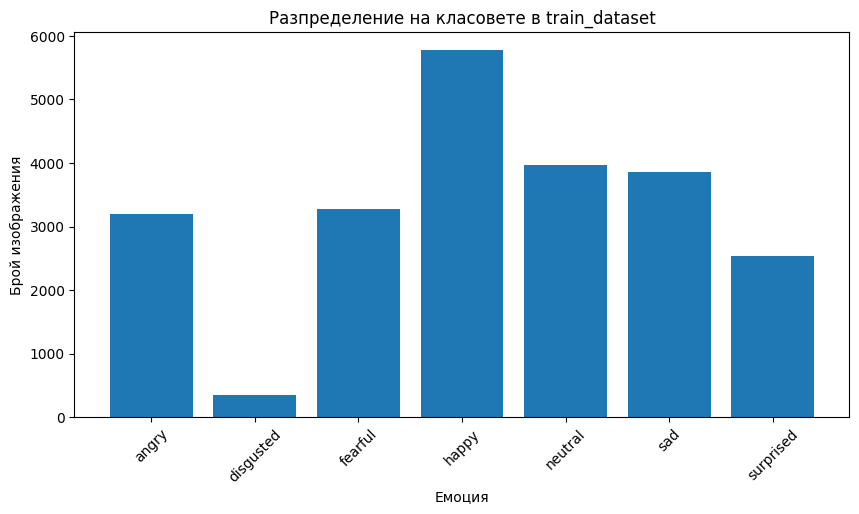

angry: 3196 изображения
disgusted: 349 изображения
fearful: 3277 изображения
happy: 5772 изображения
neutral: 3972 изображения
sad: 3864 изображения
surprised: 2537 изображения


In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Извличаме етикетите от train_dataset
train_labels = [label for _, label in train_dataset]

# Преброяваме колко изображения има за всяка емоция
unique_labels, counts = np.unique(train_labels, return_counts=True)

# Визуализация с барплот
plt.figure(figsize=(10, 5))
plt.bar(EMOTIONS, counts)
plt.title('Разпределение на класовете в train_dataset')
plt.xlabel('Емоция')
plt.ylabel('Брой изображения')
plt.xticks(rotation=45)
plt.show()

# Принтираме числата
for emotion, count in zip(EMOTIONS, counts):
    print(f"{emotion}: {count} изображения")

In [31]:
# Път до тестовите изображения
TEST_IMAGES_DIR = '/kaggle/input/competitions/task-emotion-detection-cv/test/test/images'

# Трансформации за тестовия сет (без аугментация)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Създаване на тестов dataset
test_dataset = TestDataset(images_dir=TEST_IMAGES_DIR, transform=test_transform)

# DataLoader за тестовия сет
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

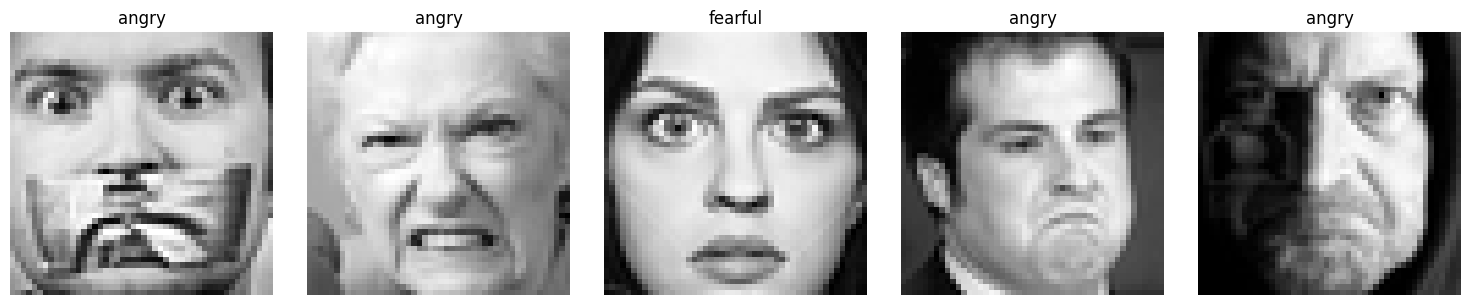

In [33]:
def plot_samples(dataset, num_samples=5):
    """Визуализира `num_samples` случайни изображения с етикети."""
    # Създаваме фигура с подходящ размер
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

    # Взимаме случайни индекси от dataset-а
    random_indices = np.random.choice(len(dataset), num_samples, replace=False)

    for i, idx in enumerate(random_indices):
        # Взимаме изображение и етикет
        img, label = dataset[idx]

        # Преобразуваме тензора обратно в изображение
        img = img.numpy().squeeze()  # Премахваме канала (C=1) и преобразуваме в numpy
        img = (img * 0.5) + 0.5      # Де-нормализираме от [-1, 1] до [0, 1]

        # Показваме изображението
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(EMOTIONS[label])  # Показваме емоцията като текст
        axes[i].axis('off')  # Премахваме осите

    plt.tight_layout()  # Подреждаме изображенията
    plt.show()

# Визуализираме 5 случайни изображения от train_dataset
plot_samples(train_dataset, num_samples=5)

## ML

In [4]:
def load_images(data_dir):
    """
    Зарежда всички изображения от директория.
    
    Args:
        data_dir: път до директорията (train или test)

    Returns:
        X: numpy масив с изображения (N, 48, 48)
        y: numpy масив с labels (N,)
    """
    images = []
    labels = []

    files = os.listdir(data_dir)
        
    for filename in files:
        filepath = os.path.join(data_dir, filename)
            
        try:
            # Зареждаме изображението като grayscale
            img = Image.open(filepath).convert('L')
            img_array = np.array(img)
                
            # Проверяваме размера
            if img_array.shape == (IMG_HEIGHT, IMG_WIDTH):
                images.append(img_array)
                # labels.append(label_idx)
            else:
                print(f"Пропускаме {filename}: грешен размер {img_array.shape}")
                    
        except Exception as e:
            print(f"Грешка при {filename}: {e}")
    
    return np.array(images)

In [5]:
print("=" * 50)
print("ЗАРЕЖДАНЕ НА TRAIN ДАННИ")
print("=" * 50)
X_train_full = load_images(TRAIN_DIR)

print(f"\nЗаредени: {len(X_train_full)} изображения")
print(f"X shape: {X_train_full.shape}")
y_train_full = pd.read_csv(TRAIN_LABELS)["label"]
print(f"y shape: {y_train_full.shape}")

ЗАРЕЖДАНЕ НА TRAIN ДАННИ

Заредени: 28709 изображения
X shape: (28709, 48, 48)
y shape: (28709,)


In [7]:
print("=" * 50)
print("ЗАРЕЖДАНЕ НА TEST ДАННИ")
print("=" * 50)
X_test= load_images(TEST_DIR)

print(f"\nЗаредени: {len(X_test)} изображения")
print(f"X shape: {X_test.shape}")

ЗАРЕЖДАНЕ НА TEST ДАННИ

Заредени: 3587 изображения
X shape: (3587, 48, 48)


# Базово решение

## Deep Learning

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm  # За прогресен бар

class EmotionCNN(nn.Module):
    def __init__(self):
        super(EmotionCNN, self).__init__()
        # CNN слоеве
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # Вход: 1 канал (grayscale)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)  # Намаляваме размера 2 пъти
        self.dropout = nn.Dropout(0.5)  # За предотвратяване на overfitting

        # Fully connected слоеве
        self.fc1 = nn.Linear(128 * 6 * 6, 512)  # 6x6 след 3 pooling слоя (48 -> 24 -> 12 -> 6)
        self.fc2 = nn.Linear(512, 7)  # 7 класа за емоции

    def forward(self, x):
        # CNN част
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.relu(self.conv3(x))
        x = self.pool(x)

        # Преобразуване в 1D вектор
        x = x.view(-1, 128 * 6 * 6)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [27]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=30):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    best_val_acc = 0.0

    for epoch in range(epochs):
        # Обучение
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}'):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # Валидиране
        val_loss, val_acc = validate_model(model, val_loader, criterion, device)

        print(f'Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

        # Запазване на най-добрия модел
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_emotion_cnn.pth')

    print(f'Training complete. Best Val Acc: {best_val_acc:.2f}%')

def validate_model(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total
    return val_loss, val_acc

In [28]:
# Инициализиране на модел, загуба и оптимизатор
model = EmotionCNN()
criterion = nn.CrossEntropyLoss()  # Подходящо за класификация
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam оптимизатор

In [29]:
# Стартиране на обучението
train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=30  # Може да се промени
)

Epoch 1/30: 100%|██████████| 359/359 [00:13<00:00, 26.63it/s]


Epoch 1: Train Loss: 1.6713, Train Acc: 32.79%, Val Loss: 1.5293, Val Acc: 42.32%


Epoch 2/30: 100%|██████████| 359/359 [00:07<00:00, 47.31it/s]


Epoch 2: Train Loss: 1.4722, Train Acc: 43.32%, Val Loss: 1.3582, Val Acc: 47.84%


Epoch 3/30: 100%|██████████| 359/359 [00:07<00:00, 45.73it/s]


...

Epoch 28: Train Loss: 0.6167, Train Acc: 77.15%, Val Loss: 1.1598, Val Acc: 60.03%


Epoch 29/30: 100%|██████████| 359/359 [00:07<00:00, 46.17it/s]


Epoch 29: Train Loss: 0.5981, Train Acc: 77.58%, Val Loss: 1.1620, Val Acc: 60.31%


Epoch 30/30: 100%|██████████| 359/359 [00:07<00:00, 49.37it/s]


Epoch 30: Train Loss: 0.5808, Train Acc: 78.36%, Val Loss: 1.1571, Val Acc: 59.96%
Training complete. Best Val Acc: 60.68%


In [35]:
def generate_predictions(model, test_loader, device):
    """
    Генерира предсказания за тестовия сет и ги записва във формат:
    image_id, label
    """
    model.eval()  # Превключваме модела в режим на оценка
    predictions = []

    with torch.no_grad():
        for images, image_ids in tqdm(test_loader, desc='Generating predictions'):
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)  # Взимаме индекса на най-вероятната емоция

            # Запазваме резултатите
            for img_id, pred in zip(image_ids, predicted.cpu().numpy()):
                predictions.append({
                    'image_id': img_id,
                    'label': EMOTIONS[pred]
                })

    return predictions

# Зареждане на най-добрия модел
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Генериране на предсказания
predictions = generate_predictions(model, test_loader, device)

# Записване в DataFrame и CSV
import pandas as pd
predictions_df = pd.DataFrame(predictions)
predictions_df.to_csv('submission1.csv', index=False)

print("Predictions saved to submission.csv")
print(predictions_df.head())  # Показваме първите 5 реда

Generating predictions: 100%|██████████| 57/57 [00:01<00:00, 44.42it/s]

Predictions saved to submission.csv
     image_id      label
0  032651.png      happy
1  030927.png      happy
2  032631.png    neutral
3  035178.png  surprised
4  034419.png    fearful


## ML


In [8]:
# Изглаждане към 1D вектор за ML алгоритми
X_train_flat = X_train_full.reshape(X_train_full.shape[0], -1)
print(f"  X_train_full: {X_train_full.shape} -> {X_train_flat.shape}")
print(f"  Всяко изображение е вектор с {X_train_flat.shape[1]} характеристики (48*48)")


  X_train_full: (28709, 48, 48) -> (28709, 2304)
  Всяко изображение е вектор с 2304 характеристики (48*48)


In [9]:
# Разделяне на тренировъчно и валидационно множество
X_train, X_val, y_train, y_val = train_test_split(
    X_train_flat, 
    y_train_full,
    test_size=VALIDATION_SPLIT,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y_train_full  # Запазва пропорциите на класовете
)

print(f"Train set: {X_train.shape[0]} изображения")
print(f"Validation set: {X_val.shape[0]} изображения")
print(f"\nФормат на данните: {X_train.shape}")

Train set: 22967 изображения
Validation set: 5742 изображения

Формат на данните: (22967, 2304)


In [10]:
# Базов модел 

baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50, svd_solver="full")),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

baseline_pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('pca', PCA(n_components=50, svd_solver='full')),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [11]:
start = time.perf_counter()
baseline_pipeline.fit(X_train, y_train)
training_time = time.perf_counter() - start

pca = baseline_pipeline.named_steps["pca"]
forest = baseline_pipeline.named_steps["classifier"]
print(f"Време за обучение: {training_time:.2f} s")
print(f"Първоначални признаци: {X_train.shape[1]}")
print(f"PCA компоненти: {pca.n_components_}")
print(f"Запазена вариация: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Брой дървета: {len(forest.estimators_)}")

Време за обучение: 29.54 s
Първоначални признаци: 2304
PCA компоненти: 50
Запазена вариация: 0.8360
Брой дървета: 100


In [12]:
start = time.perf_counter()
y_pred = baseline_pipeline.predict(X_val)
y_prob = baseline_pipeline.predict_proba(X_val)
inference_time = time.perf_counter() - start

macro_f1 = f1_score(y_val, y_pred, average="macro")

print(f"Macro F1: {macro_f1:.4f}")

Macro F1: 0.1051


In [12]:
# Създайте вашият модел тук 

# Сменете best_model с избрания от Вас модел 

best_model = baseline_pipeline

# Генериране на файл за предаване 

In [13]:
# Генериране на етикети
X_test_flat = X_test.reshape(X_test.shape[0], -1)
print("Размер на тестови данни: ", X_test_flat.shape)

Размер на тестови данни:  (3587, 2304)


In [14]:
# Генериране на етикети
y_test = best_model.predict(X_test_flat)
print("Размер на тестови етикети: ", y_test.shape)

Размер на тестови етикети:  (3587,)


In [15]:
# Отваряне и генериране submission_file
submission_df = pd.read_csv(SUBMISSION_FILE, )
print("Размер на файл за предаване: ", submission_df.shape)
print("Колони: ", submission_df.columns)

Размер на файл за предаване:  (3587, 2)
Колони:  Index(['image_id', 'label'], dtype='object')


In [19]:
submission_df.head()

,image_id,label
0,028710.png,happy
1,028711.png,happy
2,028712.png,happy
3,028713.png,happy
4,028714.png,happy


In [20]:
# Добавете своитe имена
SUBMISSION_FILE = "task3_submission_FirstName_LastName.csv"

submission_df['label'] = y_test

submission_df.to_csv(SUBMISSION_FILE, index=False)